# Import packages

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder, LabelBinarizer, PolynomialFeatures
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    recall_score
)

random_seed=42
figures_path="figures"

In [2]:
def save_figure(output_path, figure_name, fig=None, dpi=300, ext="png", show=True):
    """
    Save a matplotlib figure to output_path/figure_name.ext, creating the
    directory if it doesn't exist yet.

    output_path : folder to save into, e.g. "figures"
    figure_name : filename without extension, e.g. "risklevel_distribution"
    fig         : the Figure object to save; defaults to the current figure
                  (plt.gcf()), so it works whether you built the plot with
                  plt.figure() or fig, axes = plt.subplots()
    dpi         : resolution — 300 is print-quality, fine for a report
    ext         : file format, e.g. "png" or "pdf"
    show        : if True, displays the plot after saving (call this in place
                  of plt.show()); if False, closes it instead (useful in loops)
    """
    if fig is None:
        fig = plt.gcf()

    os.makedirs(output_path, exist_ok=True)

    filename = figure_name if figure_name.lower().endswith(f".{ext}") else f"{figure_name}.{ext}"
    filepath = os.path.join(output_path, filename)

    fig.savefig(filepath, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {filepath}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return filepath

# Load dataset

In [3]:
data_path = './data/Maternal Health Risk Data Set.csv'
df = pd.read_csv(data_path)
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [4]:
print(f"Number of participants: {len(df)}")
print(f"Number of variables: {df.shape[1]}")

# Missing values
print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))

# Numeric variables
numeric_cols = df.select_dtypes(include=np.number).columns

print("\nDescriptive statistics:")
display(df[numeric_cols].describe().T)

Number of participants: 1014
Number of variables: 7

Missing values:
Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Age,1014.0,29.871795,13.474386,10.0,19.0,26.0,39.0,70.0
SystolicBP,1014.0,113.198225,18.403913,70.0,100.0,120.0,120.0,160.0
DiastolicBP,1014.0,76.460552,13.885796,49.0,65.0,80.0,90.0,100.0
BS,1014.0,8.725986,3.293532,6.0,6.9,7.5,8.0,19.0
BodyTemp,1014.0,98.665089,1.371384,98.0,98.0,98.0,98.0,103.0
HeartRate,1014.0,74.301775,8.088702,7.0,70.0,76.0,80.0,90.0


heartrate of 7 doesn't seem valid. body temp seems to be farenheight and the range is valid. 

# Risk level distribution

Saved: figures/risklevel_distribution_bar.png


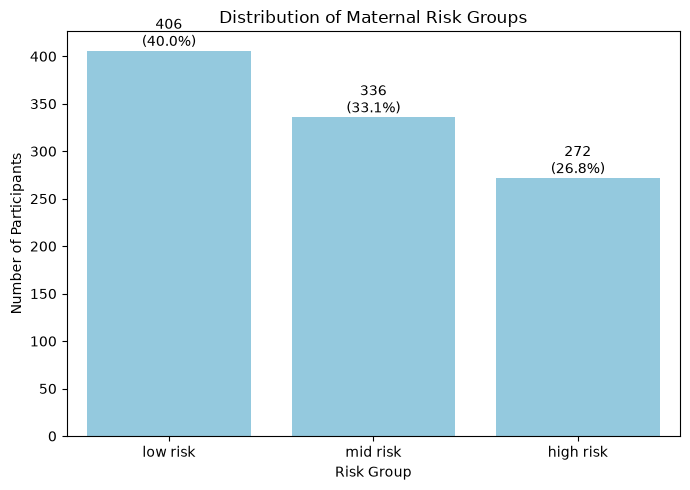

In [5]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x='RiskLevel',
    order=["low risk", "mid risk", "high risk"],
    color='skyblue'
)

plt.title("Distribution of Maternal Risk Groups")
plt.xlabel("Risk Group")
plt.ylabel("Number of Participants")

total = len(df)

for container in ax.containers:
    labels = []
    for bar in container:
        count = int(bar.get_height())
        percentage = count / total * 100
        labels.append(f"{count}\n({percentage:.1f}%)")
    ax.bar_label(container, labels=labels)

plt.tight_layout()
save_figure(figures_path, "risklevel_distribution_bar")
plt.show()

# Distribution of clinical variables

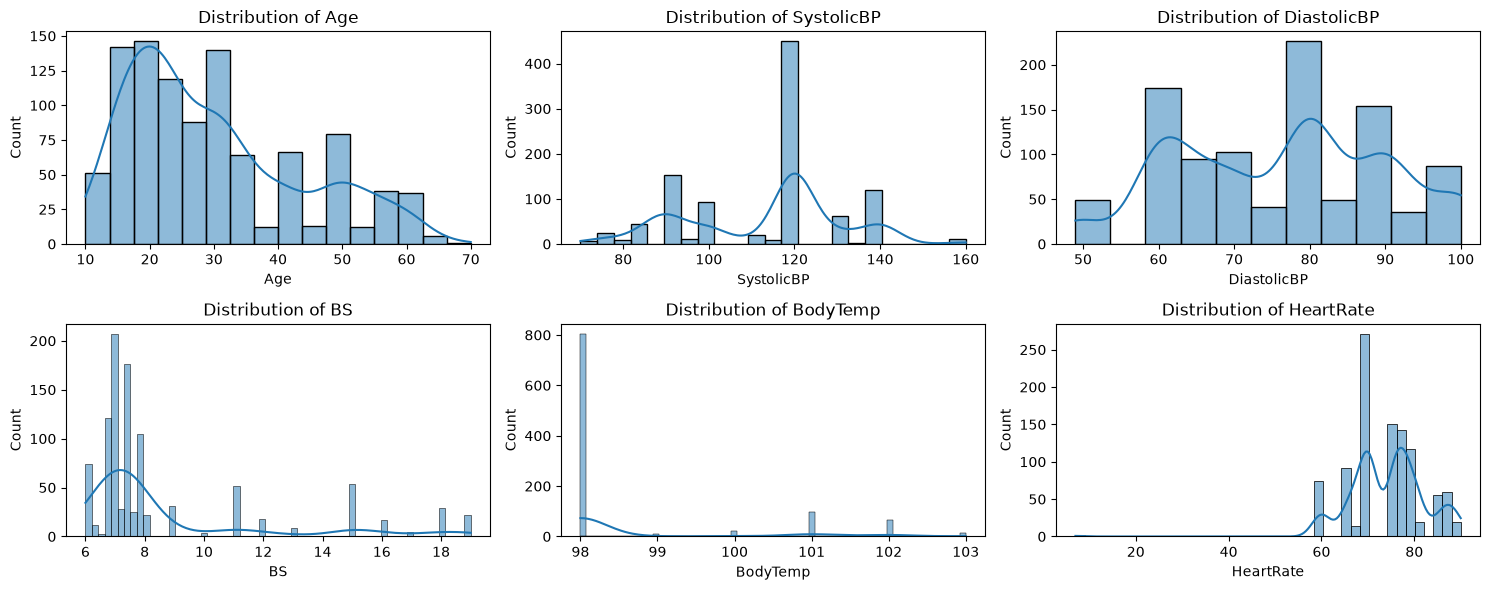

In [6]:
n_cols = 3
n_rows = 2

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 3 * n_rows)
)

axes = np.array(axes).flatten()

for ax, col in zip(axes, numeric_cols):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=ax
    )

    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

# Hide unused axes
for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

# Data quality check and cleaning

## inspect implausible clinical values

In [7]:
plausible_ranges = {
    "Age":        (10, 70),
    "SystolicBP": (70, 200),
    "DiastolicBP": (40, 120),
    "BS":         (3, 25),
    "BodyTemp":   (95, 104),
    "HeartRate":  (40, 200),
}

invalid_mask = pd.Series(False, index=df.index)

for col, (low, high) in plausible_ranges.items():
    invalid_mask |= ~df[col].between(low, high)


implausible_records = df.loc[invalid_mask].copy()

print("Number of implausible records:", len(implausible_records))
print("\nImplausible records:")
print(implausible_records)


print("\n--- Implausible values by variable ---")

for col, (low, high) in plausible_ranges.items():

    mask = ~df[col].between(low, high)

    if mask.any():
        print(f"\n{col} (plausible range: {low}–{high})")
        print(df.loc[mask, [col, "RiskLevel"]])

Number of implausible records: 2

Implausible records:
     Age  SystolicBP  DiastolicBP   BS  BodyTemp  HeartRate RiskLevel
499   16         120           75  7.9      98.0          7  low risk
908   16         120           75  7.9      98.0          7  low risk

--- Implausible values by variable ---

HeartRate (plausible range: 40–200)
     HeartRate RiskLevel
499          7  low risk
908          7  low risk


## Fix implausible clinical values

In [8]:
for col, (low, high) in plausible_ranges.items():

    mask = ~df[col].between(low, high)

    # Replace implausible values with NaN
    df.loc[mask, col] = pd.NA


numeric_cols = list(plausible_ranges.keys())

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

## Inspect duplicate values

In [9]:
dupe_mask = df.duplicated(keep=False)
print(f"Rows involved in duplicates: {dupe_mask.sum()} of {len(df)}")

# Do duplicates always share the same label, or does the same feature combo
# sometimes get different risk labels? (label noise vs. true duplication)
dupes = df[dupe_mask]
label_variation = dupes.groupby(list(df.columns.drop('RiskLevel'))).nunique()['RiskLevel']
print(f"Feature combos with >1 distinct label: {(label_variation > 1).sum()}")

# Are duplicates concentrated in one risk group? (hints at artifact vs. coincidence)
print(dupes['RiskLevel'].value_counts(normalize=True))
print(df['RiskLevel'].value_counts(normalize=True))

Rows involved in duplicates: 866 of 1014
Feature combos with >1 distinct label: 21
RiskLevel
mid risk     0.387991
low risk     0.337182
high risk    0.274827
Name: proportion, dtype: float64
RiskLevel
low risk     0.400394
mid risk     0.331361
high risk    0.268245
Name: proportion, dtype: float64


## Fix duplicate values

In [10]:
print(f"Total rows: {len(df)}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate rows by RiskLevel:\n{df[df.duplicated(keep=False)]['RiskLevel'].value_counts()}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"\nRows after dedup: {len(df)}")
print(df['RiskLevel'].value_counts(normalize=True))

Total rows: 1014
Duplicate rows: 562
Duplicate rows by RiskLevel:
RiskLevel
mid risk     336
low risk     292
high risk    238
Name: count, dtype: int64

Rows after dedup: 452
RiskLevel
low risk     0.517699
high risk    0.247788
mid risk     0.234513
Name: proportion, dtype: float64


# EDA

## Summary statistics by risk group

In [11]:
numeric_cols = [
    "Age",
    "SystolicBP",
    "DiastolicBP",
    "BS",
    "BodyTemp",
    "HeartRate"
]

summary = df.groupby("RiskLevel")[numeric_cols].agg(
    ["mean", "median"]
)

print(summary.round(2))

             Age        SystolicBP        DiastolicBP            BS         \
            mean median       mean median        mean median   mean median   
RiskLevel                                                                    
high risk  33.73   33.5     119.49  120.0       81.54   80.0  11.17   11.0   
low risk   27.32   22.0     105.44  100.0       72.73   75.0   7.20    7.2   
mid risk   28.54   25.5     112.41  120.0       74.89   77.5   7.89    7.0   

          BodyTemp        HeartRate         
              mean median      mean median  
RiskLevel                                   
high risk    99.23   98.0     76.48   77.0  
low risk     98.36   98.0     73.06   72.5  
mid risk     98.86   98.0     73.90   76.0  


## Boxplots

Saved: figures/variables_across_risk_level_box.png


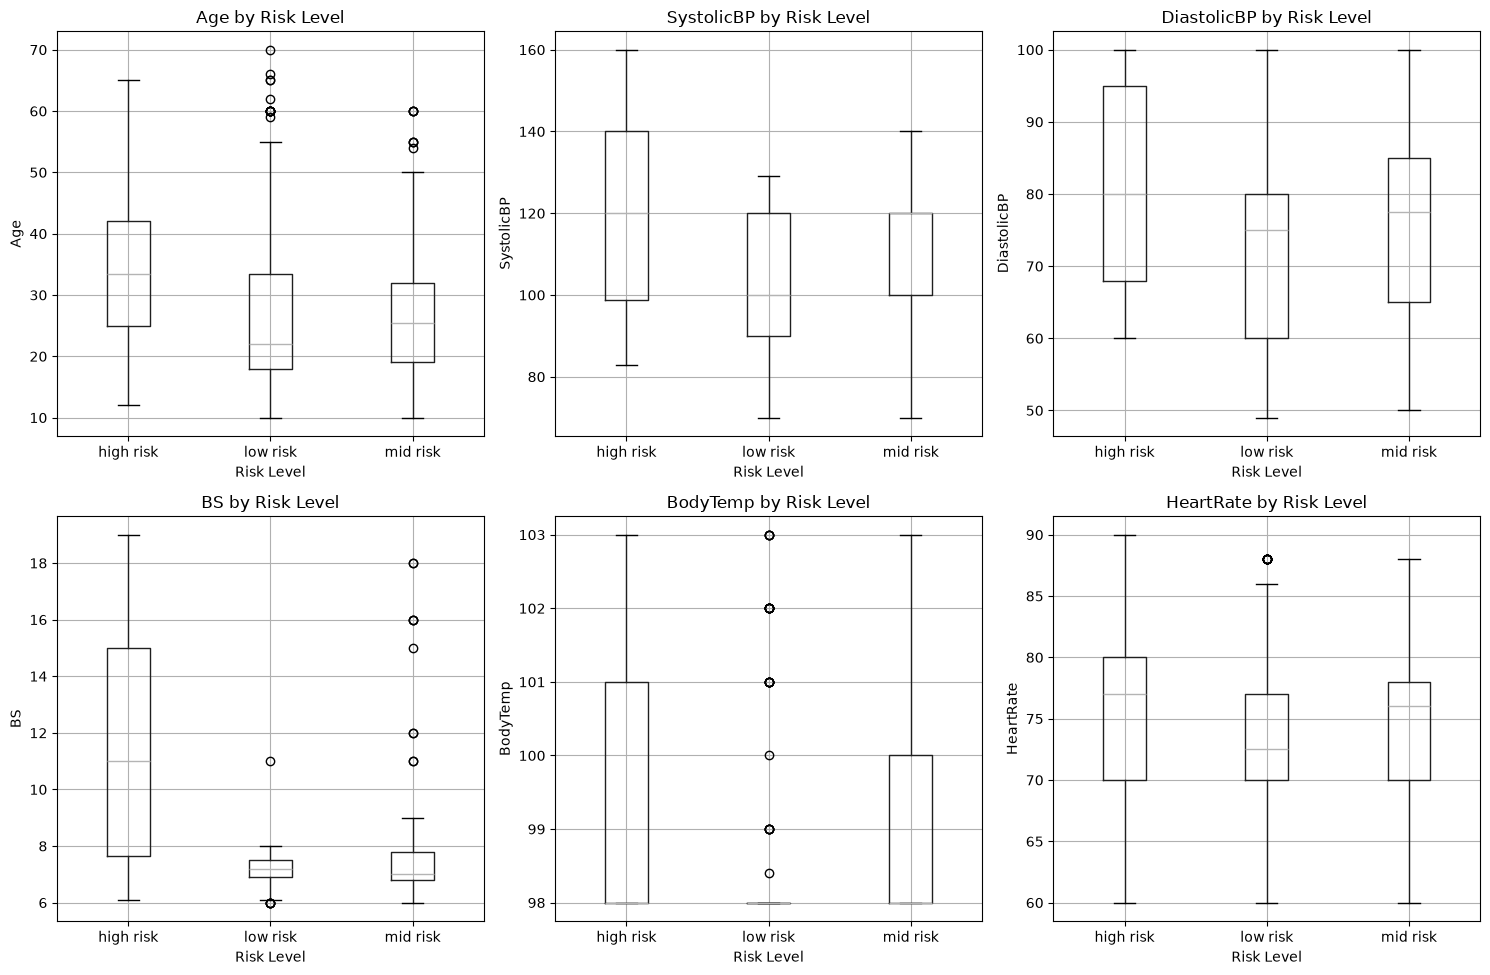

'figures/variables_across_risk_level_box.png'

In [12]:
n_cols = 3
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = np.array(axes).flatten()

for ax, col in zip(axes, numeric_cols):
    df.boxplot(
        column=col,
        by="RiskLevel",
        ax=ax
    )
    ax.set_title(f"{col} by Risk Level")
    ax.set_xlabel("Risk Level")
    ax.set_ylabel(col)

# Hide unused axes
for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

fig.suptitle("")  # kills the automatic pandas groupby suptitle
plt.tight_layout()
save_figure(figures_path, "variables_across_risk_level_box", fig=fig)

## Scatterplots

Saved: figures/bs_vs_age_by_risk_level_scatter.png


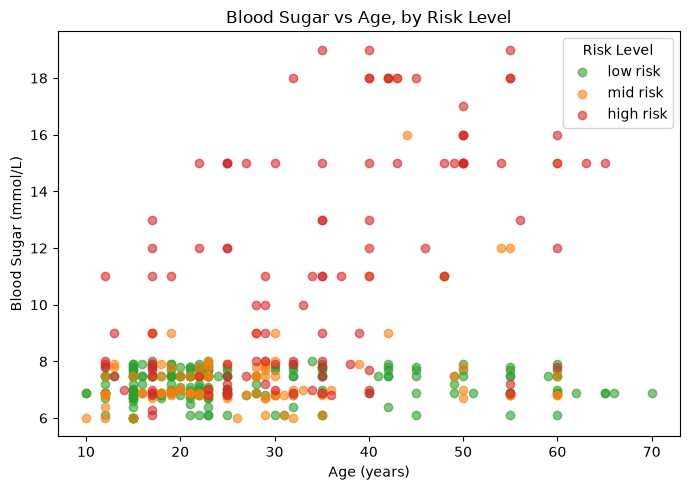

In [13]:
plt.figure(figsize=(7, 5))

palette = {"low risk": "tab:green", "mid risk": "tab:orange", "high risk": "tab:red"}

for level, color in palette.items():
    subset = df[df["RiskLevel"] == level]
    plt.scatter(subset["Age"], subset["BS"], label=level, alpha=0.6, color=color)

plt.title("Blood Sugar vs Age, by Risk Level")
plt.xlabel("Age (years)")
plt.ylabel("Blood Sugar (mmol/L)")
plt.legend(title="Risk Level")
plt.tight_layout()
save_figure(figures_path, "bs_vs_age_by_risk_level_scatter", plt.gcf())
plt.show()

## Variables most associated with High Risk

In [14]:
associations_df = df.copy()
associations_df["HighRisk"] = (associations_df["RiskLevel"] == "high risk").astype(int)

correlations = (
    associations_df[numeric_cols + ["HighRisk"]]
    .corr()["HighRisk"]
    .drop("HighRisk")
    .sort_values(key=abs, ascending=False)
)

print(correlations.round(3))

BS             0.573
SystolicBP     0.287
DiastolicBP    0.256
BodyTemp       0.218
Age            0.189
HeartRate      0.182
Name: HighRisk, dtype: float64


Saved: figures/clinical_vars_with_risk_association_bar.png


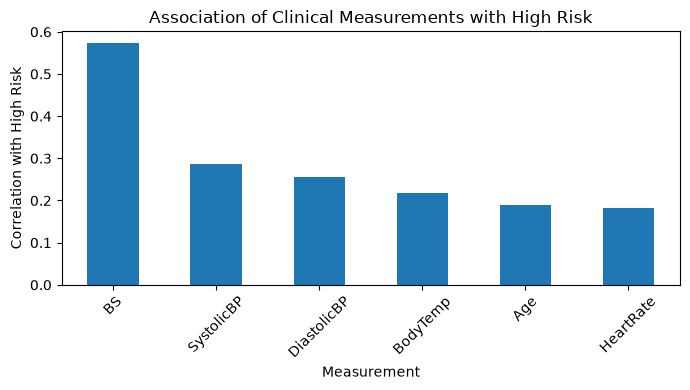

In [15]:
plt.figure(figsize=(7, 4))

correlations.plot(kind="bar")

plt.title("Association of Clinical Measurements with High Risk")
plt.ylabel("Correlation with High Risk")
plt.xlabel("Measurement")
plt.xticks(rotation=45)

plt.tight_layout()
save_figure(figures_path, "clinical_vars_with_risk_association_bar")
plt.show()

# Logistic regression model

## Create dataset splits

In [7]:
target = "RiskLevel"

X = df.drop(columns=[target])
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=random_seed)

## Create pipeline

In [8]:
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=10000))
])

lr_hyper_params = [
    {
        # 'saga' supports multiclass and all l1_ratio settings (L1, L2, ElasticNet)
        "lr__solver": ["saga"],
        "lr__l1_ratio": [0, 0.5, 1], # 0=L2, 0.5=ElasticNet, 1=L1
        "lr__C": np.logspace(-4, 4, 10),
        "lr__class_weight": [None, "balanced"],
    },
    {
        # 'lbfgs' supports multiclass but ONLY L2 regularization (l1_ratio must be 0)
        "lr__solver": ["lbfgs"],
        "lr__C": np.logspace(-4, 4, 10),
        "lr__class_weight": [None, "balanced"],
    },
]

lr_grid = GridSearchCV(
    estimator=lr_model,
    param_grid=lr_hyper_params,
    cv=5,
    scoring="recall_macro",
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...iter=10000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'lr__C': array([1.0000...00000000e+04]), 'lr__class_weight': [None, 'balanced'], 'lr__l1_ratio': [0, 0.5, ...], 'lr__solver': ['saga']}, {'lr__C': array([1.0000...00000000e+04]), 'lr__class_weight': [None, 'balanced'], 'lr__solver': ['lbfgs']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refi

## Evaluation

In [9]:
y_pred = lr_grid.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.63%

Classification Report:
              precision    recall  f1-score   support

   high risk       0.72      0.81      0.76        47
    low risk       0.61      0.79      0.68        80
    mid risk       0.59      0.36      0.44        76

    accuracy                           0.63       203
   macro avg       0.64      0.65      0.63       203
weighted avg       0.62      0.63      0.61       203



## Polynomial features

In [10]:
poly_lr_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000))
])

poly_lr_hyper_params = {
    "poly__degree": [1, 2],
    "lr__C": [0.01, 0.1, 1, 10, 100],
    "lr__class_weight": [None, "balanced"],
}

poly_lr_grid = GridSearchCV(
    poly_lr_model,
    poly_lr_hyper_params,
    cv=5,
    scoring="f1_macro"
)

poly_lr_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=2000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'lr__C': [0.01, 0.1, ...], 'lr__class_weight': [None, 'balanced'], 'poly__degree': [1, 2]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=

In [11]:
y_pred = poly_lr_grid.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.68%

Classification Report:
              precision    recall  f1-score   support

   high risk       0.75      0.89      0.82        47
    low risk       0.63      0.82      0.71        80
    mid risk       0.71      0.39      0.51        76

    accuracy                           0.68       203
   macro avg       0.70      0.70      0.68       203
weighted avg       0.69      0.68      0.66       203



# Decision tree model

## Create dataset

In [12]:
target = "RiskLevel"

X = df.drop(columns=[target])
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=random_seed)

## Model pipeline

In [13]:
tree_model = Pipeline([
    ("tr", DecisionTreeClassifier(criterion="entropy", random_state=random_seed))
])

tree_hyper_params = {
    "tr__max_depth": range(1, 10),
    "tr__min_samples_leaf": range(1, 20, 2),
    "tr__min_samples_split": range(2, 20, 2),
    "tr__criterion": ["entropy", "gini"]
}

tree_grid = GridSearchCV(estimator=tree_model, param_grid=tree_hyper_params, 
                           cv=5, verbose=True)
tree_grid.fit(X_train, y_train)

print("best accuracy", tree_grid.best_score_)
print(tree_grid.best_estimator_)

Fitting 5 folds for each of 1620 candidates, totalling 8100 fits
best accuracy 0.7842687268045141
Pipeline(steps=[('tr', DecisionTreeClassifier(max_depth=9, random_state=42))])


In [14]:
y_pred = tree_grid.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.72%

Classification Report:
              precision    recall  f1-score   support

   high risk       0.86      0.81      0.84        47
    low risk       0.82      0.57      0.68        80
    mid risk       0.61      0.83      0.70        76

    accuracy                           0.72       203
   macro avg       0.77      0.74      0.74       203
weighted avg       0.75      0.72      0.72       203



## Visualized and interpretable decision tree

Saved: figures/decision_tree_graph.png


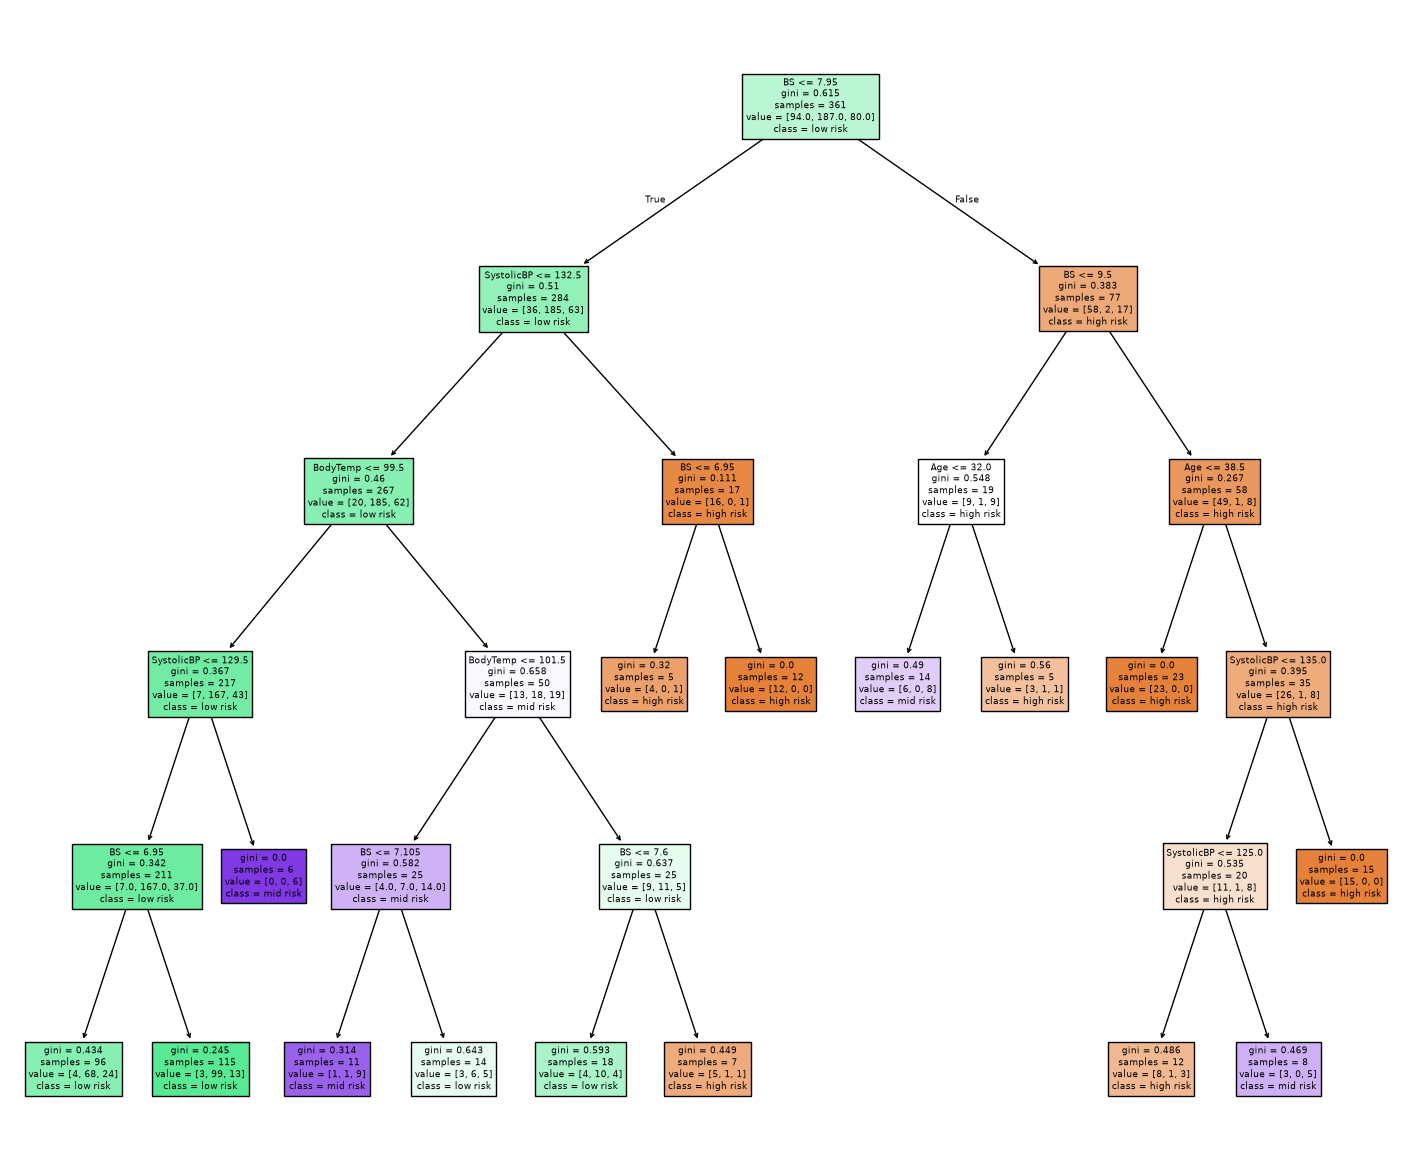

In [24]:
tree_clf = tree_grid.best_estimator_

plt.figure(figsize=(18, 15))

plot_tree(
    tree_clf["tr"],
    filled=True,
    feature_names=X_train.columns,
    class_names=tree_clf["tr"].classes_
)
save_figure(figures_path, "decision_tree_graph")
plt.show()

# Analysis

## Base Models performance compared

In [25]:
y_pred_lr = poly_lr_grid.predict(X_test)
y_pred_dt = tree_grid.predict(X_test)

def per_class_metrics(y_true, y_pred, model_name):
    report = classification_report(y_true, y_pred, output_dict=True)
    rows = [{
        "Model": model_name, "RiskLevel": label,
        "Precision": report[label]["precision"],
        "Recall": report[label]["recall"],
        "F1-score": report[label]["f1-score"],
    } for label in ["low risk", "mid risk", "high risk"]]
    return pd.DataFrame(rows)

metrics_df = pd.concat([
    per_class_metrics(y_test, y_pred_lr, "Logistic Regression"),
    per_class_metrics(y_test, y_pred_dt, "Decision Tree"),
], ignore_index=True)

metrics_df

,Model,RiskLevel,Precision,Recall,F1-score
0,Logistic Regression,low risk,0.661538,0.914894,0.767857
1,Logistic Regression,mid risk,0.500000,0.192308,0.277778
2,Logistic Regression,high risk,0.875000,0.777778,0.823529
3,Decision Tree,low risk,0.686567,0.978723,0.807018
4,Decision Tree,mid risk,0.416667,0.192308,0.263158
5,Decision Tree,high risk,0.833333,0.555556,0.666667


Saved: figures/logistic_vs_tree_performance_R_F1_by_class.png


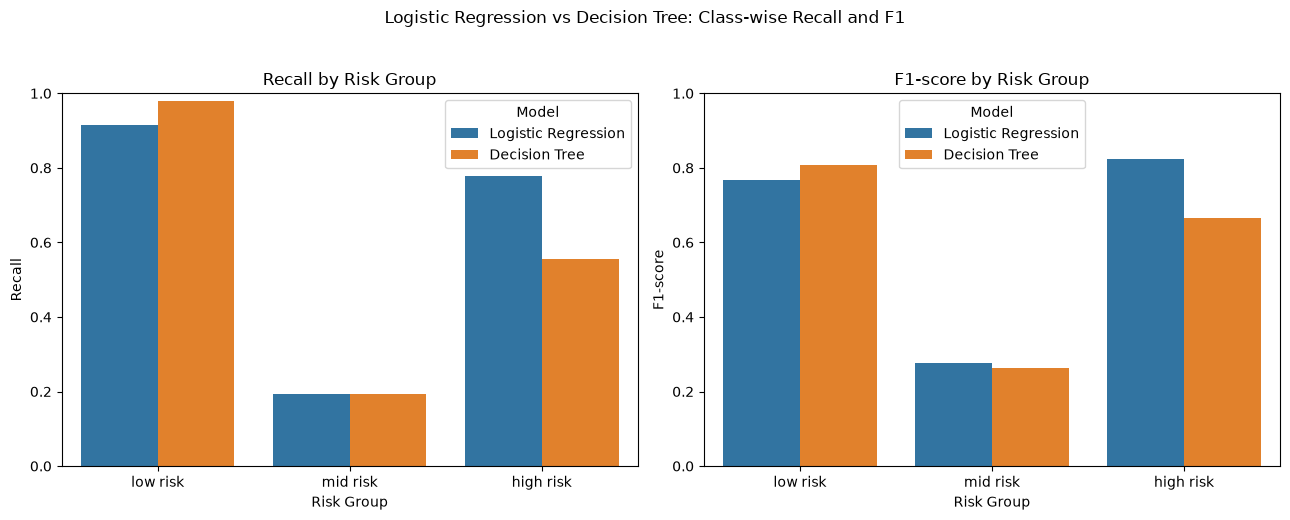

Overall accuracy — LR: 0.68, DT: 0.67


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ["Recall", "F1-score"]):
    sns.barplot(data=metrics_df, x="RiskLevel", y=metric, hue="Model",
                order=["low risk", "mid risk", "high risk"], ax=ax)
    ax.set_title(f"{metric} by Risk Group")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Risk Group")
plt.suptitle("Logistic Regression vs Decision Tree: Class-wise Recall and F1", y=1.03)
plt.tight_layout()
save_figure(figures_path, "logistic_vs_tree_performance_R_F1_by_class")
plt.show()

print(f"Overall accuracy — LR: {accuracy_score(y_test, y_pred_lr):.2f}, "
      f"DT: {accuracy_score(y_test, y_pred_dt):.2f}")

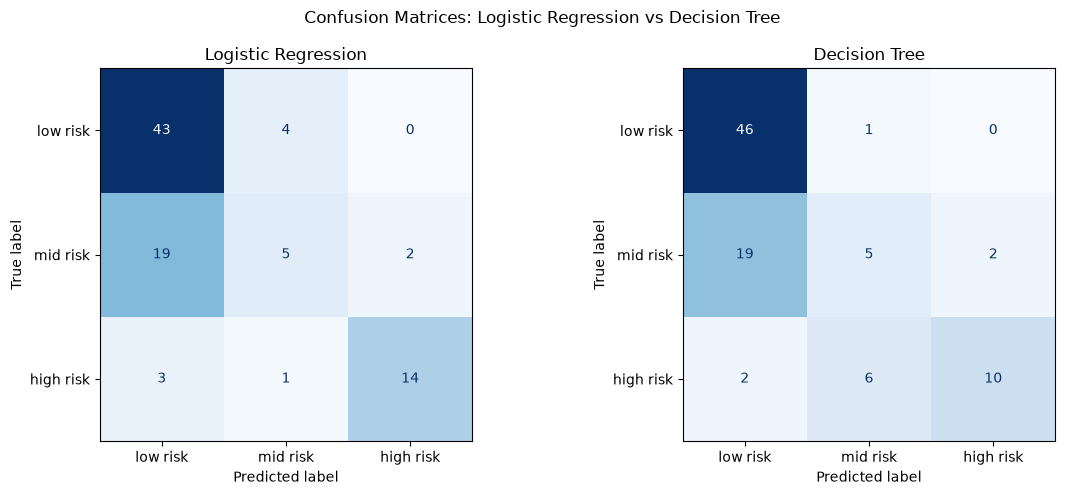

Logistic Regression: missed 4/18 true High Risk cases (22%) — these are the clinically costliest errors
Decision Tree: missed 8/18 true High Risk cases (44%) — these are the clinically costliest errors


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels_order = ["low risk", "mid risk", "high risk"]
for ax, y_pred, name in zip(axes, [y_pred_lr, y_pred_dt], ["Logistic Regression", "Decision Tree"]):
    cm = confusion_matrix(y_test, y_pred, labels=labels_order)
    ConfusionMatrixDisplay(cm, display_labels=labels_order).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.suptitle("Confusion Matrices: Logistic Regression vs Decision Tree")
plt.tight_layout()
plt.show()

# Q5: why accuracy alone is misleading — track High Risk false negatives specifically
high_mask = y_test == "high risk"
for y_pred, name in zip([y_pred_lr, y_pred_dt], ["Logistic Regression", "Decision Tree"]):
    fn = ((y_pred != "high risk") & high_mask).sum()
    print(f"{name}: missed {fn}/{high_mask.sum()} true High Risk cases "
          f"({fn/high_mask.sum():.0%}) — these are the clinically costliest errors")

## Misclassified samples

In [28]:
misclassified_X = X_test[(y_test == y_pred) == False]
misclassified_y = y_test[(y_test == y_pred) == False]

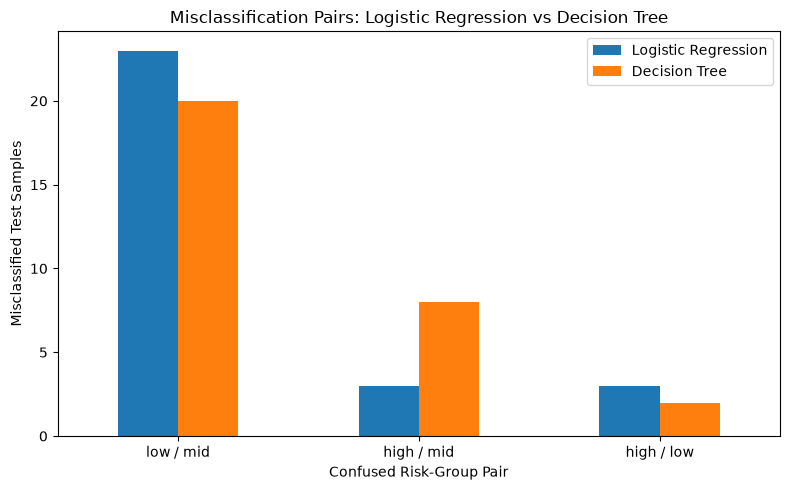

,Logistic Regression,Decision Tree
pair,,
low / mid,23,20
high / mid,3,8
high / low,3,2


In [29]:
def error_pairs(y_true, y_pred, model_name):
    df_err = pd.DataFrame({"true": y_true.values, "pred": y_pred})
    df_err = df_err[df_err["true"] != df_err["pred"]]
    df_err["pair"] = df_err.apply(
        lambda r: " / ".join(sorted([r["true"].replace(" risk", ""), r["pred"].replace(" risk", "")])),
        axis=1)
    return df_err["pair"].value_counts().rename(model_name)

error_summary = pd.concat([
    error_pairs(y_test, y_pred_lr, "Logistic Regression"),
    error_pairs(y_test, y_pred_dt, "Decision Tree"),
], axis=1).fillna(0).astype(int)

error_summary.plot(kind="bar", figsize=(8, 5))
plt.title("Misclassification Pairs: Logistic Regression vs Decision Tree")
plt.xlabel("Confused Risk-Group Pair")
plt.ylabel("Misclassified Test Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

error_summary

In [30]:
misclassified_lr = X_test.assign(true=y_test.values, pred=y_pred_lr)
misclassified_lr = misclassified_lr[misclassified_lr["true"] != misclassified_lr["pred"]]

misclassified_dt = X_test.assign(true=y_test.values, pred=y_pred_dt)
misclassified_dt = misclassified_dt[misclassified_dt["true"] != misclassified_dt["pred"]]

mid_high = {"mid risk", "high risk"}
for name, df_err in [("Logistic Regression", misclassified_lr), ("Decision Tree", misclassified_dt)]:
    overlap = df_err[df_err["true"].isin(mid_high) & df_err["pred"].isin(mid_high)]
    if len(overlap):
        print(f"\n{name} — Mid/High confusion cases: {len(overlap)}")
        display(overlap[numeric_cols].mean().to_frame("mean feature values"))


Logistic Regression — Mid/High confusion cases: 3


,mean feature values
Age,54.666667
SystolicBP,123.333333
DiastolicBP,86.666667
BS,14.333333
BodyTemp,98.000000
HeartRate,78.666667



Decision Tree — Mid/High confusion cases: 8


,mean feature values
Age,36.625
SystolicBP,112.875
DiastolicBP,78.750
BS,11.625
BodyTemp,99.125
HeartRate,76.500


## Important features

Saved: figures/logistic_vs_tree_features_contributions.png


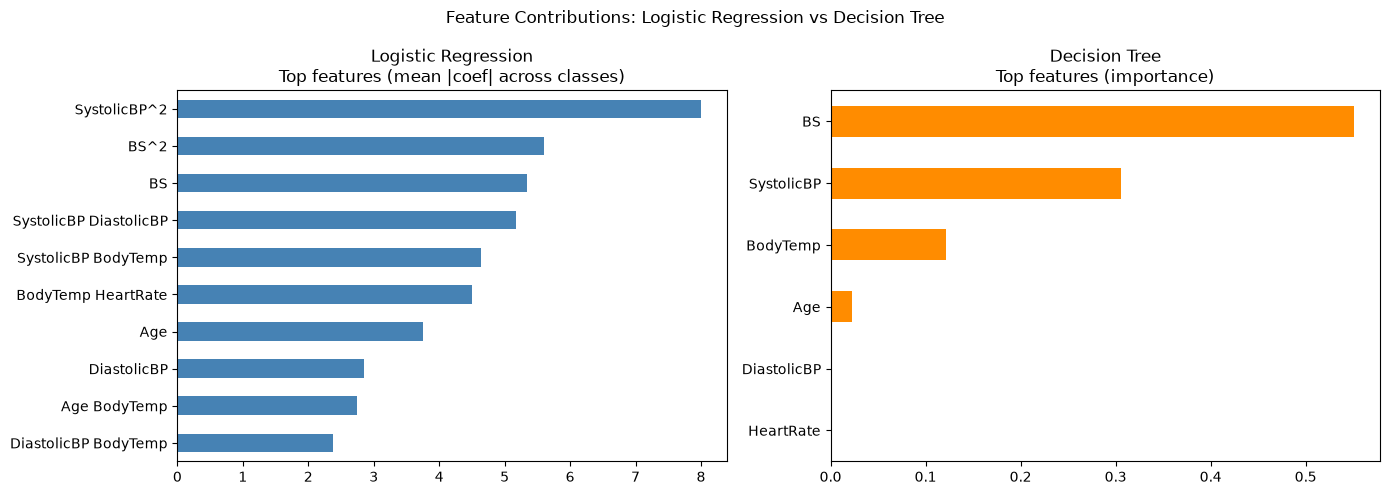

Logistic Regression - top features specifically for High Risk:
SystolicBP^2              11.991968
SystolicBP BodyTemp        6.965564
BS                         6.034569
Age                        5.626983
SystolicBP DiastolicBP     4.238404
Name: high risk, dtype: float64

Note: degree-2 polynomial terms can surface interactions (e.g. 'BS SystolicBP'). These reflect association in this sample, not causal clinical risk factors.


In [31]:
# Logistic Regression: mean |coefficient| across classes, on the poly-expanded features
# (use the FITTED best estimator from the grid search, not the unfitted base pipeline,
# and pull the fitted "poly" step from that same fitted pipeline)
lr_best = poly_lr_grid.best_estimator_
poly_lr = lr_best.named_steps["poly"]
lr_step = lr_best.named_steps["lr"]
feat_names_lr = poly_lr.get_feature_names_out(X.columns)

coef_df = pd.DataFrame(lr_step.coef_, columns=feat_names_lr, index=lr_step.classes_)
top_lr = coef_df.abs().mean(axis=0).sort_values(ascending=False).head(10)

# Decision Tree: built-in feature_importances_
# (the tree pipeline has no "poly" step -- it was never built with one -- so use the
# fitted tree directly and the original, non-expanded feature names)
dt_best = tree_grid.best_estimator_
tr_step = dt_best.named_steps["tr"]
feat_names_dt = X.columns

top_dt = pd.Series(tr_step.feature_importances_, index=feat_names_dt).sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_lr.sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Logistic Regression\nTop features (mean |coef| across classes)")
top_dt.sort_values().plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title("Decision Tree\nTop features (importance)")
plt.suptitle("Feature Contributions: Logistic Regression vs Decision Tree")
plt.tight_layout()
save_figure(figures_path, "logistic_vs_tree_features_contributions")
plt.show()

print("Logistic Regression - top features specifically for High Risk:")
print(coef_df.loc["high risk"].abs().sort_values(ascending=False).head(5))
print("\nNote: degree-2 polynomial terms can surface interactions (e.g. 'BS SystolicBP'). "
      "These reflect association in this sample, not causal clinical risk factors.")
